In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler
from datasetsforecast.m3 import M3
import warnings

warnings.filterwarnings("ignore")

In [2]:
plt.rcParams["font.size"] = 14
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["xtick.labelsize"] = 14
plt.rcParams["ytick.labelsize"] = 14
plt.rcParams["legend.fontsize"] = 14
plt.rcParams["lines.linewidth"] = 2
plt.rcParams["axes.prop_cycle"] = cycler(
    color=[
        "#000072",  # blue (for historical data)
        "#80c21d",  # green (for actual data)
        "#924eae",  # purple
        "#ff0000",  # red
        "#ff9100",  # orange
    ]
)

## Load M3 dataset

In [3]:
Y_df, *_ = M3.load(directory="../data/", group="Monthly")
Y_df["ds"] = pd.to_datetime(Y_df["ds"])

print(Y_df.head())
print(f"Number of unique time series: {Y_df['unique_id'].nunique()}")

  unique_id         ds       y
0        M1 1990-01-31  2640.0
1        M1 1990-02-28  2640.0
2        M1 1990-03-31  2160.0
3        M1 1990-04-30  4200.0
4        M1 1990-05-31  3360.0
Number of unique time series: 1428


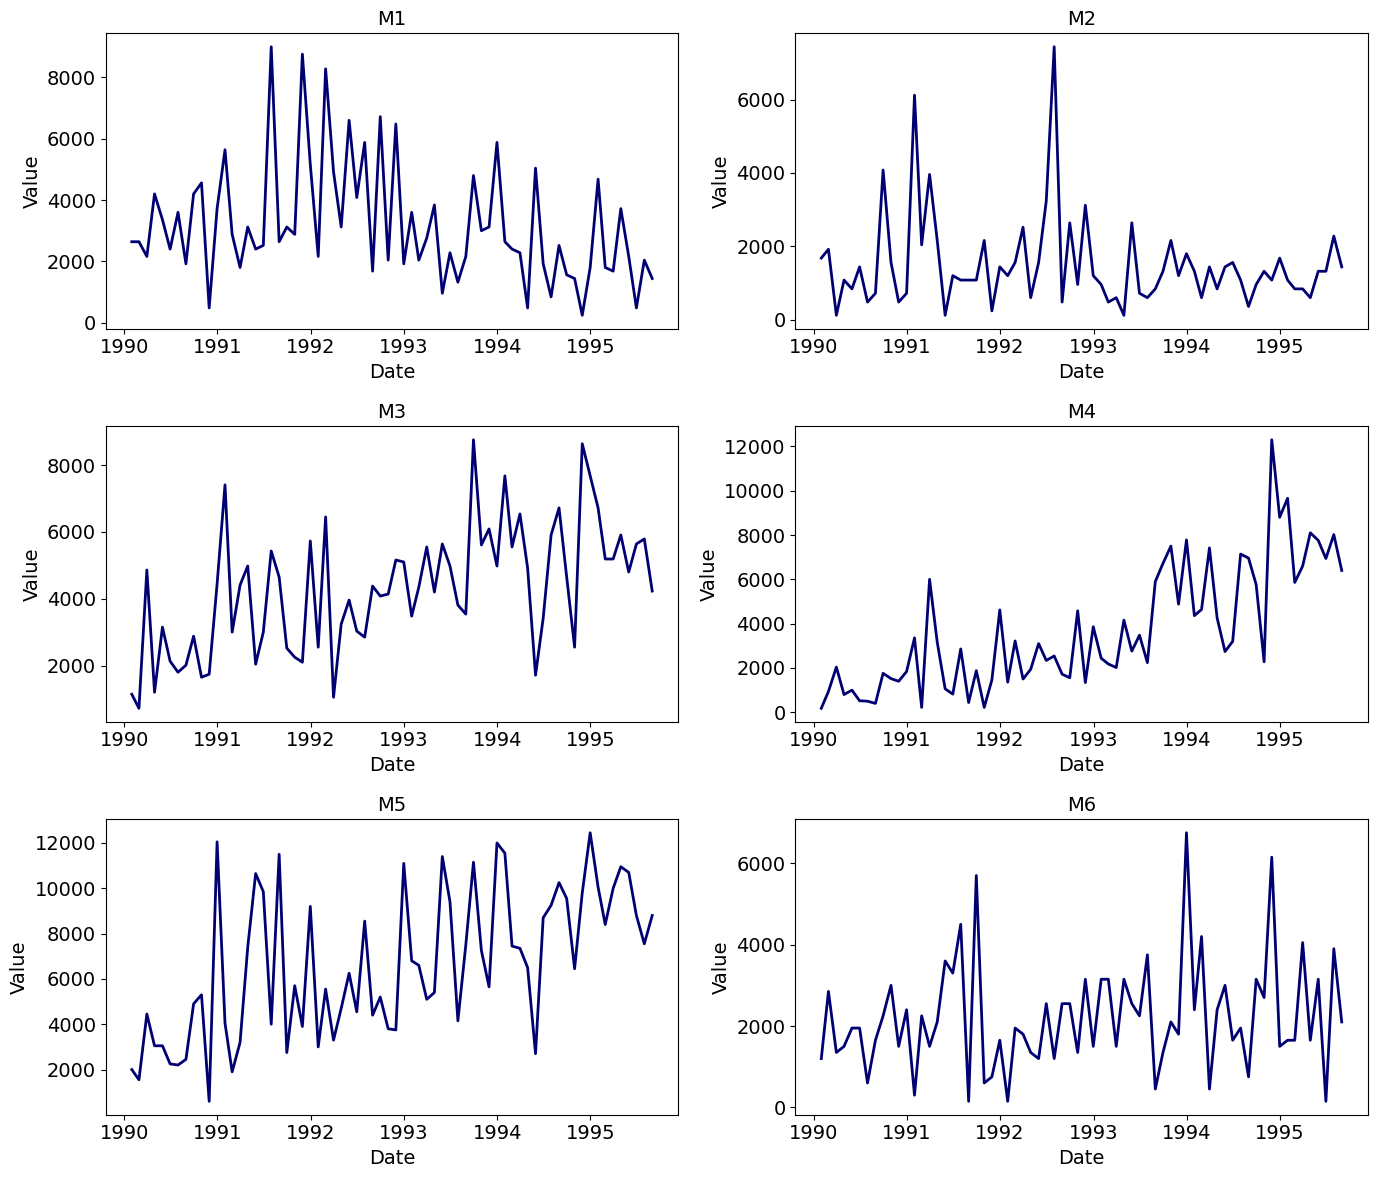

In [4]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))

for i, ax in enumerate(axes.flatten()):
    id = f"M{i+1}"
    filtered_df = Y_df[Y_df["unique_id"] == id]

    ax.plot(filtered_df["ds"], filtered_df["y"])
    ax.set_xlabel("Date")
    ax.set_ylabel("Value")
    ax.set_title(f"M{i+1}")

plt.tight_layout()

plt.savefig("figures/CH02_F03_peixeiro.png", dpi=300)
plt.savefig("figures/CH02_F03_peixeiro.pdf", format="pdf", bbox_inches="tight")

## Train model

In [5]:
from neuralforecast.core import NeuralForecast
from neuralforecast.models import NBEATS

In [6]:
# use only 1 GPU if avail
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
horizon = 12
models = [
    NBEATS(
        input_size=2 * horizon,
        h=horizon,
        max_steps=1000,
        enable_progress_bar=False,
    )
]

INFO:lightning_fabric.utilities.seed:Seed set to 1


In [7]:
nf = NeuralForecast(models=models, freq="M")
nf.fit(df=Y_df)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-02-21 02:22:41.375642: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771662161.

┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  2.4 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.4 M                                                                                            
Non-trainable params: 900                                                                                          
Total params: 2.4 M                                                                                                
Total estimated model params size (MB): 9                                                                          
Modules in train mode: 31                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO: `Trainer.fit` stopped: `max_steps=1000` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.


### Save model

In [8]:
nf.save(path="./model", model_index=None, overwrite=True, save_dataset=False)

### Load model

In [9]:
pretrained_model = NeuralForecast.load(path="./model")

INFO:lightning_fabric.utilities.seed:Seed set to 1


## Transfer learning
### Load data

In [10]:
df = pd.read_csv("../data/AusAntidiabeticDrug.csv")
df["ds"] = pd.to_datetime(df["ds"])
df["ds"] = df["ds"] + pd.offsets.MonthEnd(0)
df.insert(0, "unique_id", 1)

df.head()

,unique_id,ds,y
0,1,1991-07-31,3.526591
1,1,1991-08-31,3.180891
2,1,1991-09-30,3.252221
3,1,1991-10-31,3.611003
4,1,1991-11-30,3.565869


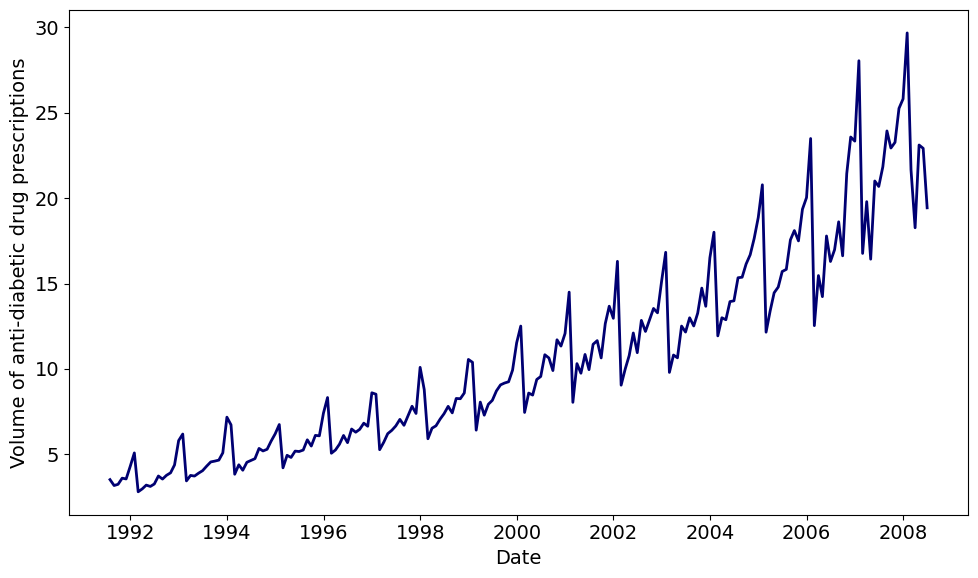

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df["ds"], df["y"])
ax.set_xlabel("Date")
ax.set_ylabel("Volume of anti-diabetic drug prescriptions")

plt.tight_layout()

plt.savefig("figures/CH02_F04_peixeiro.png", dpi=300)
plt.savefig("figures/CH02_F04_peixeiro.pdf", format="pdf", bbox_inches="tight")

In [12]:
input_df = df[:-12]
test_df = df[-12:]

### Zero-shot forecasting

In [13]:
zero_shot_preds = pretrained_model.predict(input_df)
zero_shot_preds.head()

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


,unique_id,ds,NBEATS
0,1,2007-07-31,20.577793
1,1,2007-08-31,21.961466
2,1,2007-09-30,22.017231
3,1,2007-10-31,24.110590
4,1,2007-11-30,25.277975


### Fine-tuning

In [14]:
def set_max_steps(nf, max_steps):
    trainer_kwargs = {**{"max_steps": max_steps}}
    nf.models[0].trainer_kwargs = trainer_kwargs


set_max_steps(pretrained_model, 10)

In [15]:
pretrained_model.fit(input_df)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  2.4 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.4 M                                                                                            
Non-trainable params: 900                                                                                          
Total params: 2.4 M                                                                                                
Total estimated model params size (MB): 9                                                                          
Modules in train mode: 31                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: `Trainer.fit` stopped: `max_steps=10` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=10` reached.


In [16]:
finetuned_preds = pretrained_model.predict()
finetuned_preds.head()

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

Output()

,unique_id,ds,NBEATS
0,1,2007-07-31,21.434544
1,1,2007-08-31,22.891342
2,1,2007-09-30,21.716169
3,1,2007-10-31,25.249048
4,1,2007-11-30,25.282162


### Data-specific model

In [17]:
horizon = 12

In [18]:
models = [
    NBEATS(
        input_size=2 * horizon,
        h=horizon,
        max_steps=100,
        enable_progress_bar=False,
    )
]

nf = NeuralForecast(models=models, freq="M")
nf.fit(df=input_df)

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  2.4 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.4 M                                                                                            
Non-trainable params: 900                                                                                          
Total params: 2.4 M                                                                                                
Total estimated model params size (MB): 9                                                                          
Modules in train mode: 31                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO: `Trainer.fit` stopped: `max_steps=100` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.


In [19]:
trained_preds = nf.predict()
trained_preds.head()

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


,unique_id,ds,NBEATS
0,1,2007-07-31,21.883375
1,1,2007-08-31,22.675327
2,1,2007-09-30,22.178047
3,1,2007-10-31,25.201941
4,1,2007-11-30,26.804989


## Evaluation

In [20]:
zero_shot_preds = zero_shot_preds.rename(columns={"NBEATS": "NBEATS_pretrained"})
finetuned_preds = finetuned_preds.rename(columns={"NBEATS": "NBEATS_finetuned"})
trained_preds = trained_preds.rename(columns={"NBEATS": "NBEATS_trained"})

# test_df = pd.merge(test_df, zero_shot_preds, 'left', 'ds')
# test_df = pd.merge(test_df, finetuned_preds, 'left', 'ds')
# test_df = pd.merge(test_df, trained_preds, 'left', 'ds')

# Merge on both unique_id and ds to avoid duplicates
test_df = pd.merge(test_df, zero_shot_preds, on=["unique_id", "ds"], how="left")
test_df = pd.merge(test_df, finetuned_preds, on=["unique_id", "ds"], how="left")
test_df = pd.merge(test_df, trained_preds, on=["unique_id", "ds"], how="left")

test_df.head()

,unique_id,ds,y,NBEATS_pretrained,NBEATS_finetuned,NBEATS_trained
0,1,2007-07-31,21.834890,20.577793,21.434544,21.883375
1,1,2007-08-31,23.930204,21.961466,22.891342,22.675327
2,1,2007-09-30,22.930357,22.017231,21.716169,22.178047
3,1,2007-10-31,23.263340,24.110590,25.249048,25.201941
4,1,2007-11-30,25.250030,25.277975,25.282162,26.804989


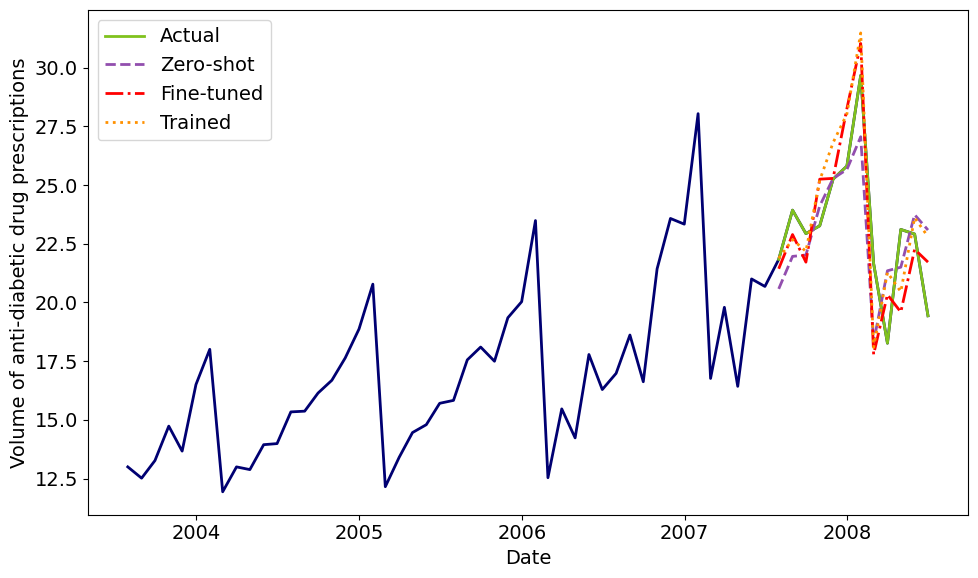

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df["ds"].iloc[-60:], df["y"].iloc[-60:])
ax.plot(test_df["ds"], test_df["y"], label="Actual")
ax.plot(test_df["ds"], test_df["NBEATS_pretrained"], ls="--", label="Zero-shot")
ax.plot(test_df["ds"], test_df["NBEATS_finetuned"], ls="-.", label="Fine-tuned")
ax.plot(test_df["ds"], test_df["NBEATS_trained"], ls=":", label="Trained")

ax.set_xlabel("Date")
ax.set_ylabel("Volume of anti-diabetic drug prescriptions")

ax.legend(loc="best")

plt.tight_layout()

plt.savefig("figures/CH02_F05_peixeiro.png", dpi=300)
plt.savefig("figures/CH02_F05_peixeiro.pdf", format="pdf", bbox_inches="tight")

In [22]:
from utilsforecast.losses import mae, smape
from utilsforecast.evaluation import evaluate

evaluation = evaluate(
    test_df,
    metrics=[mae, smape],
    models=["NBEATS_pretrained", "NBEATS_finetuned", "NBEATS_trained"],
    target_col="y",
)

evaluation = evaluation.drop(["unique_id"], axis=1)
evaluation = evaluation.set_index("metric")
evaluation

,NBEATS_pretrained,NBEATS_finetuned,NBEATS_trained
metric,,,
mae,1.690126,1.738661,1.906168
smape,0.038439,0.039311,0.042247


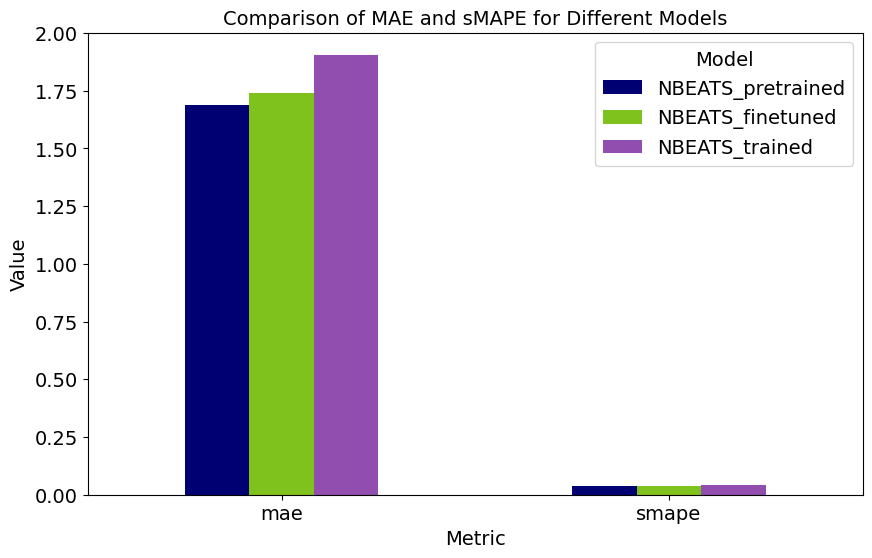

In [23]:
ax = evaluation.plot(kind="bar", figsize=(10, 6), rot=0)

# Adding labels and title
plt.xlabel("Metric")
plt.ylabel("Value")
plt.title("Comparison of MAE and sMAPE for Different Models")
plt.legend(title="Model")

# Show plot
plt.show()

## Forecasting another frequency

In [24]:
daily_df = pd.read_csv("../data/daily_min_temp.csv")
daily_df = daily_df.rename(columns={"Date": "ds", "Temp": "y"})
daily_df["ds"] = pd.to_datetime(daily_df["ds"])
daily_df.insert(0, "unique_id", 1)

daily_df.head()

,unique_id,ds,y
0,1,1981-01-01,20.7
1,1,1981-01-02,17.9
2,1,1981-01-03,18.8
3,1,1981-01-04,14.6
4,1,1981-01-05,15.8


In [25]:
d_input_df = daily_df[:-12]
d_test_df = daily_df[-12:]

### Zero-shot forecasting

In [26]:
pretrained_model = NeuralForecast.load(path="./model")

d_zero_shot_preds = pretrained_model.predict(d_input_df)
d_zero_shot_preds.head()

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


,unique_id,ds,NBEATS
0,1,1981-12-31,15.924026
1,1,1982-01-31,16.296621
2,1,1982-02-28,16.847254
3,1,1982-03-31,17.158497
4,1,1982-04-30,18.263477


### Training a model

In [27]:
models = [
    NBEATS(
        input_size=2 * horizon,
        h=horizon,
        max_steps=500,
        enable_progress_bar=False,
    )
]

nf = NeuralForecast(models=models, freq="D")
nf.fit(df=d_input_df)

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  2.4 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.4 M                                                                                            
Non-trainable params: 900                                                                                          
Total params: 2.4 M                                                                                                
Total estimated model params size (MB): 9                                                                          
Modules in train mode: 31                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO: `Trainer.fit` stopped: `max_steps=500` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.


In [28]:
d_trained_preds = nf.predict()
d_trained_preds.head()

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


,unique_id,ds,NBEATS
0,1,1981-12-20,13.625140
1,1,1981-12-21,12.497241
2,1,1981-12-22,12.627471
3,1,1981-12-23,12.147133
4,1,1981-12-24,12.201622


### Evaluation

In [29]:
d_zero_shot_preds = d_zero_shot_preds.rename(columns={"NBEATS": "NBEATS_zero_shot"})
d_zero_shot_preds = d_zero_shot_preds.reset_index(drop=True)
d_trained_preds = d_trained_preds.rename(columns={"NBEATS": "NBEATS_trained"})

# d_test_df = pd.merge(d_test_df, d_trained_preds, "left", "ds")
d_test_df = pd.merge(d_test_df, d_trained_preds, on=["unique_id", "ds"], how="left")
d_test_df = pd.concat([d_test_df, d_zero_shot_preds["NBEATS_zero_shot"]], axis=1)

print(d_test_df)

    unique_id         ds     y  NBEATS_trained  NBEATS_zero_shot
0           1 1981-12-20  11.0       13.625140         15.924026
1           1 1981-12-21  11.1       12.497241         16.296621
2           1 1981-12-22  15.0       12.627471         16.847254
3           1 1981-12-23  12.8       12.147133         17.158497
4           1 1981-12-24  15.0       12.201622         18.263477
5           1 1981-12-25  14.2       14.429667         15.145281
6           1 1981-12-26  14.0       14.779531         16.278711
7           1 1981-12-27  15.5       12.604039         16.928871
8           1 1981-12-28  13.3       11.713346         15.280169
9           1 1981-12-29  15.6       13.010280         18.440666
10          1 1981-12-30  15.2       15.033627         17.945723
11          1 1981-12-31  17.4       15.605682         16.478868


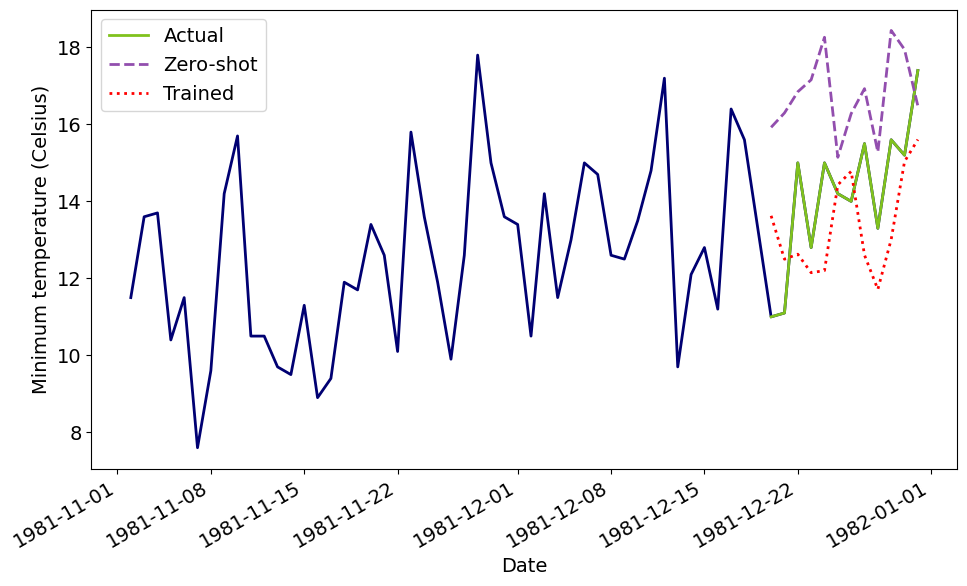

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(daily_df["ds"].iloc[-60:], daily_df["y"].iloc[-60:])
ax.plot(d_test_df["ds"], d_test_df["y"], label="Actual")
ax.plot(d_test_df["ds"], d_test_df["NBEATS_zero_shot"], ls="--", label="Zero-shot")
ax.plot(d_test_df["ds"], d_test_df["NBEATS_trained"], ls=":", label="Trained")

ax.set_xlabel("Date")
ax.set_ylabel("Minimum temperature (Celsius)")

ax.legend(loc="best")

plt.tight_layout()
fig.autofmt_xdate()

plt.savefig("figures/CH02_F06_peixeiro.png", dpi=300)
plt.savefig("figures/CH02_F06_peixeiro.pdf", format="pdf", bbox_inches="tight")

In [31]:
d_evaluation = evaluate(
    d_test_df,
    metrics=[mae, smape],
    models=["NBEATS_zero_shot", "NBEATS_trained"],
    target_col="y",
)

d_evaluation = d_evaluation.drop(["unique_id"], axis=1)
d_evaluation = d_evaluation.set_index("metric")
d_evaluation

,NBEATS_zero_shot,NBEATS_trained
metric,,
mae,2.727536,1.657365
smape,0.090705,0.061059
